### Step 1: Load the raw data

We use the UCI **Online Retail** dataset, which contains all transactions
from a UK-based online gift retailer between *December 2010* and *December
2011* (541,909 rows). Each row is one product line within one invoice,
with the product description, quantity sold, unit price, invoice date,
customer ID, and country.

In [11]:
import pandas as pd

In [21]:
df = pd.read_excel("Online Retail.xlsx")
print(df.shape)

(541909, 8)


### Step 2: Load the category mapping

Individual product descriptions (e.g. "WHITE HANGING HEART T-LIGHT
HOLDER") are too granular to forecast one by one — there are over 4,000
distinct products. We use a category mapping (provided for this
internship) that groups similar products into ~55 broader categories
(e.g. "Tealight Holders & Sets"), which gives us series with enough
volume and regularity to model.

In [27]:
import json

with open("products_to_categories.json") as f:
    categories = json.load(f)

print(f"Number of mapped products: {len(categories)}")
# peek at a few entries
list(categories.items())[:5]

Number of mapped products: 3866


[('bird house hot water bottle', 'Hot Water Bottles'),
 ('charlie + lola red hot water bottle', 'Hot Water Bottles'),
 ('charlie lola blue hot water bottle', 'Hot Water Bottles'),
 ('charlie+lola pink hot water bottle', 'Hot Water Bottles'),
 ('charlie+lola red hot water bottle', 'Hot Water Bottles')]

### Step 3: Clean the data

Before aggregating, we remove rows that don't represent real sales:
- Cancelled orders (invoice numbers starting with "C") — these are
  returns, not sales.
- Administrative line items such as postage, discounts, and bank
  charges, which aren't products.
- Rows with zero or negative quantity/price, which are data entry
  artifacts rather than genuine transactions.

In [32]:
# Drop cancellations (invoice numbers starting with "C")
df_clean = df[~df["InvoiceNo"].astype(str).str.startswith("C")].copy()

# Drop administrative line items (postage, discounts, fees, manual adjustments)
admin_codes = ["POST", "D", "M", "C2", "DOT", "BANK CHARGES", "CRUK", "S", "PADS"]
df_clean = df_clean[~df_clean["StockCode"].astype(str).str.upper().isin(admin_codes)]

# Keep only positive quantity and positive price
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["UnitPrice"] > 0)]

print("Rows before cleaning:", len(df))
print("Rows after cleaning:", len(df_clean))

Rows before cleaning: 541909
Rows after cleaning: 527792


### Step 4: Map products to categories

Each cleaned transaction's product description is matched (case-
insensitive) against the category mapping from Step 2, so every row is
tagged with its category. Descriptions with no match (a small fraction,
mostly non-product noise) are labeled "Unclassified".

In [37]:
# Normalize description text (lowercase, strip whitespace) to match the JSON keys
df_clean["desc_norm"] = df_clean["Description"].astype(str).str.strip().str.lower()

# Look up each description in the category dictionary; anything unmatched becomes "Unclassified"
df_clean["Category"] = df_clean["desc_norm"].map(categories).fillna("Unclassified")

# Check how well the mapping worked
unclassified_share = (df_clean["Category"] == "Unclassified").mean()
print(f"Share of rows Unclassified: {unclassified_share*100:.2f}%")

df_clean[["Description", "Category"]].head(10)

Share of rows Unclassified: 0.15%


,Description,Category
0,WHITE HANGING HEART T-LIGHT HOLDER,Tealight Holders & Sets
1,WHITE METAL LANTERN,Lanterns
2,CREAM CUPID HEARTS COAT HANGER,"Coat Racks, Hooks & Hangers"
3,KNITTED UNION FLAG HOT WATER BOTTLE,Hot Water Bottles
4,RED WOOLLY HOTTIE WHITE HEART.,Hot Water Bottles
5,SET 7 BABUSHKA NESTING BOXES,Miscellaneous
6,GLASS STAR FROSTED T-LIGHT HOLDER,Tealight Holders & Sets
7,HAND WARMER UNION JACK,Hand Warmers & Umbrellas
8,HAND WARMER RED POLKA DOT,Hand Warmers & Umbrellas
9,ASSORTED COLOUR BIRD ORNAMENT,Miscellaneous


### Step 5: Aggregate to daily category-level sales

We sum quantities by day and category to get one time series per
category. Days with no recorded sales for a given category are
explicitly filled in as zero — this matters because gaps would
otherwise be invisible to a forecasting model and bias it.

In [40]:
# Extract just the date (drop the time) and compute revenue per line
df_clean["Date"] = df_clean["InvoiceDate"].dt.date
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

# Sum quantity, revenue, and count distinct orders, per day per category
daily = (
    df_clean.groupby(["Date", "Category"])
    .agg(Quantity=("Quantity", "sum"), Revenue=("Revenue", "sum"), Orders=("InvoiceNo", "nunique"))
    .reset_index()
)

# Build a complete grid of every (date, category) combination, so missing days become explicit zeros
daily["Date"] = pd.to_datetime(daily["Date"])
all_dates = pd.date_range(daily["Date"].min(), daily["Date"].max(), freq="D")
all_categories = daily["Category"].unique()
full_index = pd.MultiIndex.from_product([all_dates, all_categories], names=["Date", "Category"])

daily = daily.set_index(["Date", "Category"]).reindex(full_index, fill_value=0).reset_index()

print(f"Date range: {daily['Date'].min().date()} to {daily['Date'].max().date()}")
print(f"Number of days: {daily['Date'].nunique()}")
print(f"Number of categories: {daily['Category'].nunique()}")
daily.head()

Date range: 2010-12-01 to 2011-12-09
Number of days: 374
Number of categories: 55


,Date,Category,Quantity,Revenue,Orders
0,2010-12-01,"Bag Charms, Key Rings & Phone Charms",1,1.66,1
1,2010-12-01,"Bags, Purses & Backpacks",683,1338.68,26
2,2010-12-01,"Baskets, Hampers & Wicker",83,336.66,14
3,2010-12-01,Cake Cases & Baking Accessories,879,866.83,18
4,2010-12-01,Cake Stands,160,1720.27,19


In [44]:
daily.to_csv("daily_category_sales.csv", index=False)

### Step 6: Exploratory data analysis

Before modeling, we visualize the daily sales to spot trend, seasonality,
and any irregularities that should inform model choice.

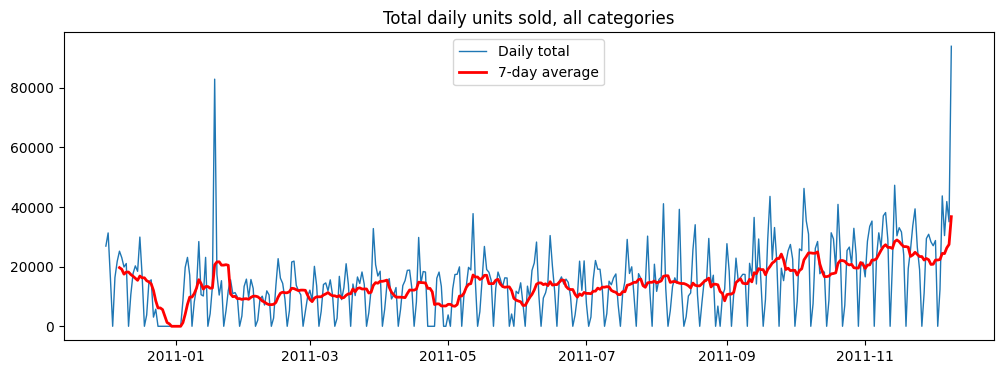

weekday
Monday       16432.830189
Tuesday      20984.094340
Wednesday    18982.277778
Thursday     22363.222222
Friday       16497.129630
Saturday         0.000000
Sunday        8878.056604
Name: Quantity, dtype: float64


In [47]:
import matplotlib.pyplot as plt

overall = daily.groupby("Date")["Quantity"].sum()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(overall.index, overall.values, lw=1, label="Daily total")
ax.plot(overall.index, overall.rolling(7).mean(), lw=2, color="red", label="7-day average")
ax.set_title("Total daily units sold, all categories")
ax.legend()
plt.show()

# Average sales by day of week
overall_df = overall.reset_index()
overall_df["weekday"] = overall_df["Date"].dt.day_name()
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_avg = overall_df.groupby("weekday")["Quantity"].mean().reindex(order)
print(weekday_avg)